In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('stock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

In [15]:
df['Close_diff'] = df['Close'].diff()
df.dropna(inplace=True)

In [16]:
!pip install statsmodels

In [17]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\acer\anaconda3\Lib\site-packa

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2033
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5264.403
Date:                Wed, 01 Apr 2026   AIC                          10540.806
Time:                        03:50:42   BIC                          10574.507
Sample:                             0   HQIC                         10553.170
                               - 2033                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0113      0.016     -0.724      0.469      -0.042       0.019
ar.L2          0.0162      0.017      0.975      0.330      -0.016       0.049
ar.L3          0.0197      0.017      1.186      0.2

C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


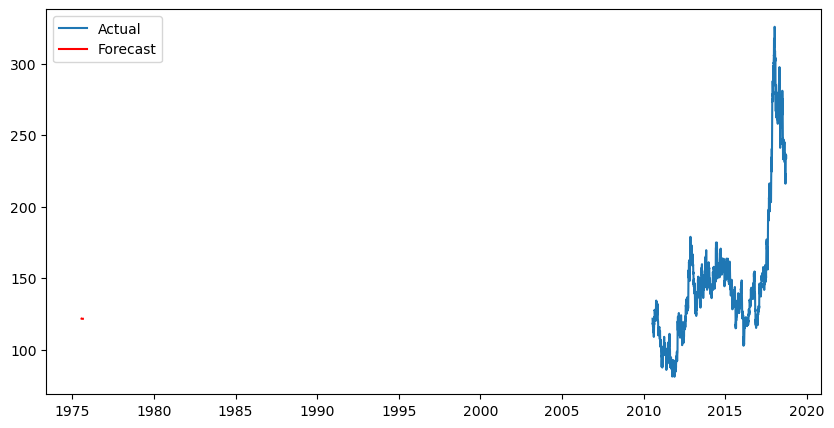

In [18]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close']])

In [20]:
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

In [22]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [24]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 7.7 MB/s eta 0:00:46
   ---------------------------------------- 3.7/351.2 MB 9.7 MB/s eta 0:00:36
    --------------------------------------- 5.8/351.2 MB 9.6 MB/s eta 0:00:37
    --------------------------------------- 8.1/351.2 MB 10.0 MB/s eta 0:00:35
   - -------------------------------------- 10.2/351.2 MB 10.0 MB/s eta 0:00:35
   - -------------------------------------- 12.3/351.2 MB 9.8 MB/s eta 0:00:35
   - -------------------------------------- 14.2/351.2 MB 9.7 MB/s eta 0:00:35
   - -------------------------------------- 16.0/351.2 MB 9.6 MB/s eta 0:00:35
   -- ------------------------------------- 18.1/351.2 MB 9.6 MB/s eta 0:00:35
   -- ------------------------------------- 20.2/351.2 MB 9.7 MB/s eta 0:00:35
   -- ------------------------------------- 22.3/351.2 MB 9.7 MB/s eta 0:00:34
   -- ------------------------------------- 24.1/351.2 MB 9.7 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32)

C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0078
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 9.1266e-04
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 8.2490e-04
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 8.1265e-04
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 7.3092e-04
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.0464e-04
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 7.8248e-04
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 6.3745e-04
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 5.8193e-04
Epoch 10/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.5269e-04


In [26]:
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [27]:
plot(model.predict(X))

NameError: name 'plot' is not defined

In [ ]:
2+4